In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("ache_ic50_clean.csv")

df = df[np.isfinite(df["pIC50"])].copy()

print(df.shape)
df.head()

(6287, 4)


,molecule_chembl_id,canonical_smiles,pIC50,n_measurements
0,CHEMBL100334,CN(CCOCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,6.920819,1
1,CHEMBL100366,CN1CC[C@@]2(C)c3cc(OC(=O)Nc4ccccc4)ccc3N(C=O)C12,6.107683,1
2,CHEMBL100510,CN(CCOCCNC(=S)NC(=O)c1ccc2ccccc2c1)Cc1ccccc1,7.000000,1
3,CHEMBL101028,CN(CCOCCNC(=S)Nc1ccc(OC(F)(F)F)cc1)Cc1ccccc1,6.000000,1
4,CHEMBL101155,CN(CCOCCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,5.958607,1


In [2]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

In [3]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)

    scaffold = MurckoScaffold.GetScaffoldForMol(mol)

    return Chem.MolToSmiles(scaffold)

In [4]:
for smiles in df["canonical_smiles"].head(10):
    scaffold = get_scaffold(smiles)

    print("Molecule :", smiles)
    print("Scaffold :", scaffold)
    print()

Molecule : CN(CCOCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1
Scaffold : O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccccc1

Molecule : CN1CC[C@@]2(C)c3cc(OC(=O)Nc4ccccc4)ccc3N(C=O)C12
Scaffold : O=C(Nc1ccccc1)Oc1ccc2c(c1)C1CCNC1N2

Molecule : CN(CCOCCNC(=S)NC(=O)c1ccc2ccccc2c1)Cc1ccccc1
Scaffold : O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccc2ccccc2c1

Molecule : CN(CCOCCNC(=S)Nc1ccc(OC(F)(F)F)cc1)Cc1ccccc1
Scaffold : S=C(NCCOCCNCc1ccccc1)Nc1ccccc1

Molecule : CN(CCOCCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1
Scaffold : O=C(NC(=S)NCCCOCCNCc1ccccc1)c1ccccc1

Molecule : CCC(C)CSC(=O)OCC[N+](C)(C)C.[Cl-]
Scaffold : 

Molecule : CN(CCOCCNC(=S)NC(=O)c1ccc(Cl)cc1)Cc1ccccc1
Scaffold : O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccccc1

Molecule : CN(CCOCCNC(=S)NC(=O)c1ccc(-c2ccccc2)cc1)Cc1ccccc1
Scaffold : O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccc(-c2ccccc2)cc1

Molecule : CN(CCOCCNC(=S)NC(=O)c1ccc(Cl)c(Cl)c1)Cc1ccccc1
Scaffold : O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccccc1

Molecule : CN(CCOCCNC(=S)Nc1ccc(Cl)cc1)Cc1ccccc1
Scaffold : S=C(NCCOCCNCc1ccccc1)Nc1ccccc1



In [5]:
from rdkit.Chem.Scaffolds import MurckoScaffold

mol = Chem.MolFromSmiles(
    "CN(CCOCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1"
)

scaffold = MurckoScaffold.GetScaffoldForMol(mol)

print(Chem.MolToSmiles(scaffold))

O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccccc1


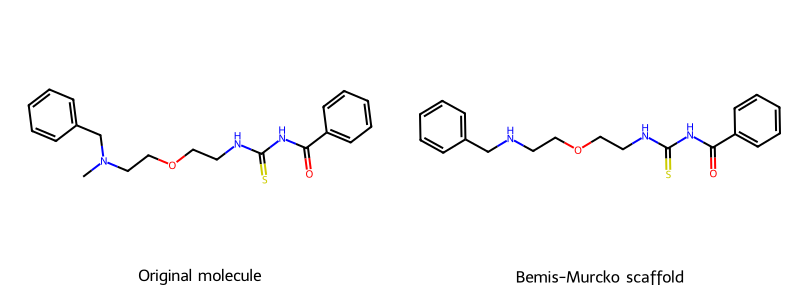

In [6]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from IPython.display import display

smiles = "CN(CCOCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1"

# Original molecule
mol = Chem.MolFromSmiles(smiles)

# Bemis-Murcko scaffold
scaffold = MurckoScaffold.GetScaffoldForMol(mol)

# Display side by side
img = Draw.MolsToGridImage(
    [mol, scaffold],
    legends=["Original molecule", "Bemis-Murcko scaffold"],
    molsPerRow=2,
    subImgSize=(400, 300)
)

display(img)

In [7]:
scaffold_List = []

for smiles in df["canonical_smiles"].head(10):
    scaffold = get_scaffold(smiles)
    scaffold_List.append(scaffold)

print(scaffold_List)

print("\nNumber of unique scaffolds:")
print(len(set(scaffold_List)))  
unique_scaffolds = set(scaffold_List)

for scaffold in unique_scaffolds:
    print(scaffold)

['O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccccc1', 'O=C(Nc1ccccc1)Oc1ccc2c(c1)C1CCNC1N2', 'O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccc2ccccc2c1', 'S=C(NCCOCCNCc1ccccc1)Nc1ccccc1', 'O=C(NC(=S)NCCCOCCNCc1ccccc1)c1ccccc1', '', 'O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccccc1', 'O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccc(-c2ccccc2)cc1', 'O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccccc1', 'S=C(NCCOCCNCc1ccccc1)Nc1ccccc1']

Number of unique scaffolds:
7

O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccc2ccccc2c1
O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccc(-c2ccccc2)cc1
S=C(NCCOCCNCc1ccccc1)Nc1ccccc1
O=C(Nc1ccccc1)Oc1ccc2c(c1)C1CCNC1N2
O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccccc1
O=C(NC(=S)NCCCOCCNCc1ccccc1)c1ccccc1


In [8]:
#Test Scaffold
small_df = df.head(10).copy()

small_df["scaffold"] = [
    get_scaffold(smiles)
    for smiles in small_df["canonical_smiles"]
]

small_df[
    ["molecule_chembl_id", "canonical_smiles", "scaffold"]
]

,molecule_chembl_id,canonical_smiles,scaffold
0,CHEMBL100334,CN(CCOCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccccc1
1,CHEMBL100366,CN1CC[C@@]2(C)c3cc(OC(=O)Nc4ccccc4)ccc3N(C=O)C12,O=C(Nc1ccccc1)Oc1ccc2c(c1)C1CCNC1N2
2,CHEMBL100510,CN(CCOCCNC(=S)NC(=O)c1ccc2ccccc2c1)Cc1ccccc1,O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccc2ccccc2c1
3,CHEMBL101028,CN(CCOCCNC(=S)Nc1ccc(OC(F)(F)F)cc1)Cc1ccccc1,S=C(NCCOCCNCc1ccccc1)Nc1ccccc1
4,CHEMBL101155,CN(CCOCCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,O=C(NC(=S)NCCCOCCNCc1ccccc1)c1ccccc1
5,CHEMBL101482,CCC(C)CSC(=O)OCC[N+](C)(C)C.[Cl-],
6,CHEMBL101518,CN(CCOCCNC(=S)NC(=O)c1ccc(Cl)cc1)Cc1ccccc1,O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccccc1
7,CHEMBL101809,CN(CCOCCNC(=S)NC(=O)c1ccc(-c2ccccc2)cc1)Cc1ccccc1,O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccc(-c2ccccc2)cc1
8,CHEMBL101940,CN(CCOCCNC(=S)NC(=O)c1ccc(Cl)c(Cl)c1)Cc1ccccc1,O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccccc1
9,CHEMBL101988,CN(CCOCCNC(=S)Nc1ccc(Cl)cc1)Cc1ccccc1,S=C(NCCOCCNCc1ccccc1)Nc1ccccc1


In [9]:
#How many molecules belong to each scaffold:
small_df["scaffold"].value_counts()

scaffold
O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccccc1               3
S=C(NCCOCCNCc1ccccc1)Nc1ccccc1                    2
O=C(Nc1ccccc1)Oc1ccc2c(c1)C1CCNC1N2               1
O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccc2ccccc2c1         1
O=C(NC(=S)NCCCOCCNCc1ccccc1)c1ccccc1              1
                                                  1
O=C(NC(=S)NCCOCCNCc1ccccc1)c1ccc(-c2ccccc2)cc1    1
Name: count, dtype: int64

In [10]:
#Print Empty String
small_df[
    small_df["scaffold"] == ""
][["molecule_chembl_id", "canonical_smiles", "scaffold"]]


,molecule_chembl_id,canonical_smiles,scaffold
5,CHEMBL101482,CCC(C)CSC(=O)OCC[N+](C)(C)C.[Cl-],


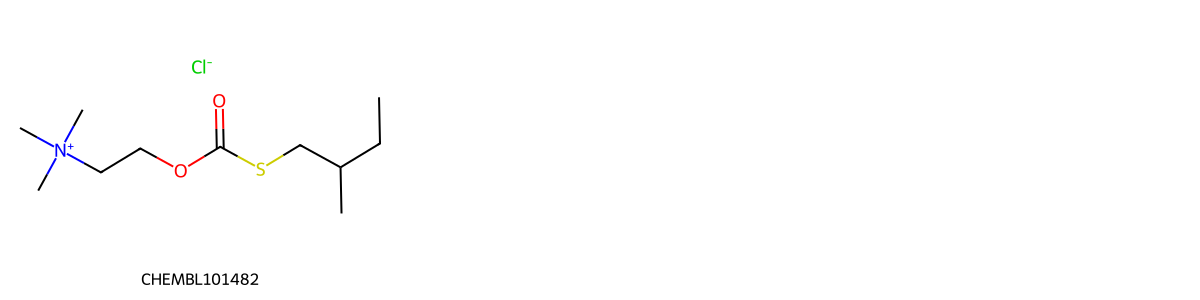

In [11]:
no_ring_df = small_df[
    small_df["scaffold"] == ""
]

no_ring_mols = [
    Chem.MolFromSmiles(smiles)
    for smiles in no_ring_df["canonical_smiles"]
]

img = Draw.MolsToGridImage(
    no_ring_mols,
    legends=no_ring_df["molecule_chembl_id"].tolist(),
    molsPerRow=3,
    subImgSize=(400, 300)
)

display(img)

In [12]:
#6287 Scaffold
All_mol_df = df.copy()

df["scaffold"] = [
    get_scaffold(smiles)
    for smiles in df["canonical_smiles"]
]

In [13]:
#How many molecules belong to each scaffold:
df["scaffold"].value_counts()

scaffold
c1ccccc1                                         152
c1ccc2nc3c(cc2c1)CCCC3                            87
c1ccc2c(c1)CCC2                                   56
                                                  38
C1=CC(c2ccccc2)c2cc3c(nc2N1)CCCC3                 35
                                                ... 
O=C1Cc2c(ccc3c(CCC4CCN(Cc5ccccc5)CC4)noc23)N1      1
C(=C/C1CCN(Cc2ccccc2)CC1)/c1noc2ccccc12            1
O=C(NCCOCCNCc1ccccc1)Nc1ccccc1                     1
c1ccc(CNCc2cccc3ccccc23)cc1                        1
S=C(NCCOCCNCc1ccccc1)NC1CCCCC1                     1
Name: count, Length: 2660, dtype: int64

In [14]:
scaffold_counts = df["scaffold"].value_counts()

print("Number of molecules:", len(df))
print("Number of unique scaffolds:", len(scaffold_counts))

print("Singleton scaffolds:", (scaffold_counts == 1).sum())
print("Scaffolds with >= 2 molecules:", (scaffold_counts >= 2).sum())
print("Scaffolds with >= 5 molecules:", (scaffold_counts >= 5).sum())
print("Scaffolds with >= 10 molecules:", (scaffold_counts >= 10).sum())

print("\nLargest scaffold family:")
print(scaffold_counts.iloc[0])

Number of molecules: 6287
Number of unique scaffolds: 2660
Singleton scaffolds: 1793
Scaffolds with >= 2 molecules: 867
Scaffolds with >= 5 molecules: 252
Scaffolds with >= 10 molecules: 120

Largest scaffold family:
152


In [15]:
from collections import defaultdict

scaffold_to_indices = defaultdict(list)

for idx, scaffold in enumerate(df["scaffold"]):
    scaffold_to_indices[scaffold].append(idx)

# Sort scaffold groups from largest to smallest
scaffold_groups = sorted(
    scaffold_to_indices.values(),
    key=len,
#    key=lambda group: len(group)
    reverse=True
)

print("Number of scaffold groups:", len(scaffold_groups))
print("Largest groups:", [len(g) for g in scaffold_groups[:10]])

Number of scaffold groups: 2660
Largest groups: [152, 87, 56, 38, 35, 32, 31, 30, 30, 28]


In [16]:
#Allocate complete scaffold grou[p
train_idx_scaffold = []
test_idx_scaffold = []

train_cutoff = int(0.8 * len(df))

for group in scaffold_groups:
    if len(train_idx_scaffold) + len(group) <= train_cutoff:
        train_idx_scaffold.extend(group)
    else:
        test_idx_scaffold.extend(group)

print("Train molecules:", len(train_idx_scaffold))
print("Test molecules :", len(test_idx_scaffold))

Train molecules: 5029
Test molecules : 1258


In [17]:
train_scaffolds = set(
    df.iloc[train_idx_scaffold]["scaffold"]
)

test_scaffolds = set(
    df.iloc[test_idx_scaffold]["scaffold"]
)

shared_scaffolds = train_scaffolds.intersection(test_scaffolds)

print("Unique train scaffolds:", len(train_scaffolds))
print("Unique test scaffolds :", len(test_scaffolds))
print("Shared scaffolds      :", len(shared_scaffolds))

Unique train scaffolds: 1402
Unique test scaffolds : 1258
Shared scaffolds      : 0


In [18]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)

    fp = morgan_gen.GetFingerprint(mol)

    arr = np.zeros((2048,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr

In [19]:
#Data Spiltting
#Convert all 6287 ligands into fingerprints
X = np.array([
    smiles_to_fp(smiles)
    for smiles in df["canonical_smiles"]
])

y = df["pIC50"].to_numpy()
X_train_scaffold = X[train_idx_scaffold]
X_test_scaffold = X[test_idx_scaffold]

y_train_scaffold = y[train_idx_scaffold]
y_test_scaffold = y[test_idx_scaffold]

print("X train:", X_train_scaffold.shape)
print("X test :", X_test_scaffold.shape)

X train: (5029, 2048)
X test : (1258, 2048)


In [20]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_scaffold = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_scaffold.fit(
    X_train_scaffold,
    y_train_scaffold
)

y_pred_scaffold = rf_scaffold.predict(X_test_scaffold)

In [21]:
#Evaluate Model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_scaffold = mean_absolute_error(
    y_test_scaffold,
    y_pred_scaffold
)

rmse_scaffold = np.sqrt(
    mean_squared_error(
        y_test_scaffold,
        y_pred_scaffold
    )
)

r2_scaffold = r2_score(
    y_test_scaffold,
    y_pred_scaffold
)

print("Scaffold split")
print("MAE :", mae_scaffold)
print("RMSE:", rmse_scaffold)
print("R²  :", r2_scaffold)

Scaffold split
MAE : 0.8013692818060552
RMSE: 1.0958982477576378
R²  : 0.43815018782284987


In [22]:
residuals = y_test_scaffold - y_pred_scaffold

print("Mean residual:", residuals.mean())
print("Largest positive residual:", residuals.max())
print("Largest negative residual:", residuals.min())

Mean residual: -0.0311671217885044
Largest positive residual: 4.88670117047082
Largest negative residual: -7.347022387488183


In [23]:
#Which molecule failed
from sklearn.model_selection import train_test_split

indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42
)

test_results = df.iloc[test_idx].copy()

test_results["experimental_pIC50"] = y_test_scaffold
test_results["predicted_pIC50"] = y_pred_scaffold
test_results["residual"] = y_test_scaffold - y_pred_scaffold
test_results["absolute_error"] = np.abs(test_results["residual"])
test_results.head()

,molecule_chembl_id,canonical_smiles,pIC50,n_measurements,scaffold,experimental_pIC50,predicted_pIC50,residual,absolute_error
4441,CHEMBL4782180,Oc1ccccc1-c1nnc(N2CCN(c3ccccn3)CC2)o1,5.910095,1,c1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,5.119186,6.733072,-1.613886,1.613886
3658,CHEMBL4278686,COc1nc(-c2ccnc(NC(=O)C3CC3)c2)sc1C(=O)NCCCNc1c...,8.193820,1,O=C(NCCCNc1c2c(nc3ccccc13)CCCC2)c1cnc(-c2ccnc(...,3.823909,5.012608,-1.188699,1.188699
6067,CHEMBL6171343,COc1ccc2c3c1O[C@H]1C[C@@H](OC(=O)NC4CCN(Cc5ccc...,6.220815,1,O=C(NC1CCN(Cc2ccccc2)CC1)O[C@H]1C=C[C@@]23CCNC...,5.126104,6.099861,-0.973756,0.973756
5319,CHEMBL5397966,CN(C)CCCN1C(=O)CSC1c1cccc(Cl)c1.Cl,4.602060,1,O=C1CSC(c2ccccc2)N1,8.795880,8.762766,0.033114,0.033114
1539,CHEMBL243062,CCN(CCCCCCNC1=C(Br)C(=O)C(NCCCCCCN(CC)Cc2ccccc...,8.575118,1,O=C1C=C(NCCCCCCNCc2ccccc2)C(=O)C=C1NCCCCCCNCc1...,6.069051,7.141327,-1.072276,1.072276


In [24]:
worst = test_results.sort_values(
    "absolute_error",
    ascending=False
)

worst[
    [
        "molecule_chembl_id",
        "canonical_smiles",
        "experimental_pIC50",
        "predicted_pIC50",
        "residual",
        "absolute_error"
    ]
].head(10)

,molecule_chembl_id,canonical_smiles,experimental_pIC50,predicted_pIC50,residual,absolute_error
1499,CHEMBL2413746,CN(C)CCOc1ccc(-c2nc3ccccc3[nH]2)cc1,0.786000,8.133022,-7.347022,7.347022
3852,CHEMBL4445345,Cc1cc(=O)oc2ccc(OC/C=C/CCn3cnc4c(N5CCCCC5)ncnc...,1.614000,8.133022,-6.519022,6.519022
1961,CHEMBL32543,CCCCCCNC(=O)Oc1ccc2c(c1)[C@@H]1CCN(CCC)C1C2,8.050610,3.163909,4.886701,4.886701
2862,CHEMBL3818089,COc1cc(/C=C/C(=O)NCCC2CCN(Cc3ccccc3)CC2)ccc1O,14.301030,9.899597,4.401433,4.401433
864,CHEMBL1770554,O=C1C=C(NCCCNCc2ccc(-c3nc4ccccc4s3)cc2)C(=O)C=...,14.301030,9.899597,4.401433,4.401433
6282,CHEMBL99284,CN1CC[C@]2(C)c3cc(OC(=O)Nc4ccccc4)ccc3NC12,8.769551,4.598683,4.170868,4.170868
1297,CHEMBL2234527,CCOC(=O)C1=C(C)Nc2nc3c(c(N)c2[C@H]1c1ccccc1[N+...,7.208855,3.225832,3.983022,3.983022
5017,CHEMBL5190129,CCCCN(CCC1CCCCCC1)Cc1ccc(OC(=O)N(C)C)c2ccccc12,8.638272,4.729834,3.908439,3.908439
4386,CHEMBL4765163,CCn1cc(CNCc2c[nH]nc2-c2ccc(-c3ccccc3)cc2)cn1,8.332547,4.488459,3.844088,3.844088
5112,CHEMBL5218632,CNC(=O)Oc1cccc(CN(C)CCCCCCCOc2ccc(-c3cc(=O)c4c...,8.892790,5.091599,3.801191,3.801191


In [25]:
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

# Fingerprints for scaffold-training molecules
train_fps_scaffold = []

for idx in train_idx_scaffold:
    mol = Chem.MolFromSmiles(
        df.iloc[idx]["canonical_smiles"]
    )
    fp = morgan_gen.GetFingerprint(mol)
    train_fps_scaffold.append(fp)

In [26]:
#Nearest training neighbor for every scaffold-test molecu

In [27]:
max_similarity_scaffold = []

for idx in test_idx_scaffold:

    mol = Chem.MolFromSmiles(
        df.iloc[idx]["canonical_smiles"]
    )

    test_fp = morgan_gen.GetFingerprint(mol)

    similarities = DataStructs.BulkTanimotoSimilarity(
        test_fp,
        train_fps_scaffold
    )

    max_similarity_scaffold.append(
        max(similarities)
    )

In [28]:
pd.Series(max_similarity_scaffold).describe()

count    1258.000000
mean        0.630441
std         0.209200
min         0.160000
25%         0.482195
50%         0.652174
75%         0.782269
max         1.000000
dtype: float64

In [29]:
import pandas as pd
import numpy as np

df = pd.read_csv("ache_ic50_clean.csv")

# Same cleaning as before
df = df[np.isfinite(df["pIC50"])].copy()

print(df.shape)
df.head()

(6287, 4)


,molecule_chembl_id,canonical_smiles,pIC50,n_measurements
0,CHEMBL100334,CN(CCOCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,6.920819,1
1,CHEMBL100366,CN1CC[C@@]2(C)c3cc(OC(=O)Nc4ccccc4)ccc3N(C=O)C12,6.107683,1
2,CHEMBL100510,CN(CCOCCNC(=S)NC(=O)c1ccc2ccccc2c1)Cc1ccccc1,7.000000,1
3,CHEMBL101028,CN(CCOCCNC(=S)Nc1ccc(OC(F)(F)F)cc1)Cc1ccccc1,6.000000,1
4,CHEMBL101155,CN(CCOCCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,5.958607,1


In [30]:
#Random-split comparison
import numpy as np
from sklearn.model_selection import train_test_split

all_idx = np.arange(len(df))

train_idx_random, test_idx_random = train_test_split(
    all_idx,
    test_size=0.2,
    random_state=42
)

print(len(train_idx_random), len(test_idx_random))

5029 1258


In [31]:
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)
train_fps_random = []

for idx in train_idx_random:
    mol = Chem.MolFromSmiles(
        df.iloc[idx]["canonical_smiles"]
    )
    fp = morgan_gen.GetFingerprint(mol)
    train_fps_random.append(fp)


max_similarity_random = []

for idx in test_idx_random:

    mol = Chem.MolFromSmiles(
        df.iloc[idx]["canonical_smiles"]
    )

    test_fp = morgan_gen.GetFingerprint(mol)

    similarities = DataStructs.BulkTanimotoSimilarity(
        test_fp,
        train_fps_random
    )

    max_similarity_random.append(
        max(similarities)
    )

In [32]:
print("Random split:")
print(pd.Series(max_similarity_random).describe())

print("\nScaffold split:")
print(pd.Series(max_similarity_scaffold).describe())

Random split:
count    1258.000000
mean        0.794769
std         0.162902
min         0.191011
25%         0.725934
50%         0.812500
75%         0.916373
max         1.000000
dtype: float64

Scaffold split:
count    1258.000000
mean        0.630441
std         0.209200
min         0.160000
25%         0.482195
50%         0.652174
75%         0.782269
max         1.000000
dtype: float64


In [33]:
scaffold_results = pd.DataFrame({
    "experimental_pIC50": y_test_scaffold,
    "predicted_pIC50": y_pred_scaffold,
    "max_train_similarity": max_similarity_scaffold
})

scaffold_results["residual"] = (
    scaffold_results["experimental_pIC50"]
    - scaffold_results["predicted_pIC50"]
)

scaffold_results["absolute_error"] = (
    scaffold_results["residual"].abs()
)

In [34]:
corr = scaffold_results[
    ["absolute_error", "max_train_similarity"]
].corr()

corr

,absolute_error,max_train_similarity
absolute_error,1.000000,-0.107822
max_train_similarity,-0.107822,1.000000
